"""
STEP 1: Batch Auto-Crop Script
==============================
Purpose: Automatically removes the dark/black borders from all your manuscript
         images and saves the cropped versions to a new folder.

How it works:
  1. It reads each image and converts it to grayscale.
  2. It scans from each edge (top, bottom, left, right) inward until it finds
     a row or column whose average brightness exceeds 100 (out of 255).
     Rows/columns darker than this are considered part of the black border.
  3. It adds a small padding (5 pixels) so we don't accidentally cut off any ink.
  4. It saves the cropped image to the output folder.

Why BRIGHTNESS_THRESHOLD = 100?
  The images have a gradual dark-to-bright transition at the edges (from the
  book binding/scanner). A threshold of 50 was too low and left dark rows in.
  A threshold of 100 reliably catches the full dark border region.

Usage:
  1. Set INPUT_FOLDER to the folder containing your original ~300+ images.
  2. Set OUTPUT_FOLDER to where you want the cropped images saved.
  3. Open a terminal (Anaconda Prompt), activate your environment, and run:
         python step1_batch_autocrop.py

Requirements: pip install Pillow numpy tqdm
"""

In [ ]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm  # Shows a progress bar

# ============================================================
# SETTINGS - Change these two paths to match your computer
# ============================================================

# The folder containing your original manuscript images
INPUT_FOLDER = r'historical-manuscript-line-segmentation\examples\input'

# The folder where cropped images will be saved (will be created automatically)
OUTPUT_FOLDER = r'historical-manuscript-line-segmentation\examples\cropped_image'




In [21]:

# ============================================================
# PARAMETERS - You can adjust these if needed
# ============================================================

# A row/column is considered "dark border" if its average pixel brightness
# is below this threshold (0=black, 255=white).
# 100 works well for these manuscript images.
BRIGHTNESS_THRESHOLD = 120 #playing with the treshold will make it more aggressive about cutting off dark borders, but be careful not to set it too low or it might miss some borders.

# After finding the crop boundary, add this many extra pixels of padding
# to avoid accidentally cutting off ink at the very edges.
PADDING = 0

# Supported image file extensions
SUPPORTED_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')

BRIGHTNESS_RATIO = 0.95
EXTRA_TRIM = 8


In [22]:
# ============================================================
# MAIN SCRIPT - No need to change anything below this line
# ============================================================

def find_crop_bounds(gray_array, threshold, padding, bright_ratio):
    """
    Finds the crop boundaries for a grayscale image array.
    
    Scans from each of the 4 edges toward the center.
    The boundary is the first row/column where the average brightness
    exceeds the threshold (meaning it's no longer a dark border).
    """
    height, width = gray_array.shape

    # True where pixel is bright enough to be manuscript/background
    bright = gray_array > threshold

    # For each row/column, calculate how much of it is bright
    row_bright_ratio = bright.mean(axis=1)
    col_bright_ratio = bright.mean(axis=0)
    
    # Scan from the top downward
    top = 0
    for i in range(height):
        if gray_array[i, :].mean() > threshold:
            top = i
            break

    # Scan from the bottom upward
    bottom = height - 1
    for i in range(height - 1, -1, -1):
        if gray_array[i, :].mean() > threshold:
            bottom = i
            break

    # Scan from the left rightward
    left = 0
    for j in range(width):
        if gray_array[:, j].mean() > threshold:
            left = j
            break

    # Scan from the right leftward
    right = width - 1
    for j in range(width - 1, -1, -1):
        if gray_array[:, j].mean() > threshold:
            right = j
            break

    # Apply padding but don't go outside the image boundaries
    top    = max(0, top - padding)
    bottom = min(height - 1, bottom + padding)
    left   = max(0, left - padding)
    right  = min(width - 1, right + padding)

    return top, bottom, left, right


In [23]:
def batch_autocrop(input_folder, output_folder, threshold, padding):
    """
    Main function: processes all images in input_folder and saves
    cropped versions to output_folder.
    """
    os.makedirs(output_folder, exist_ok=True)

    all_files = [
        f for f in sorted(os.listdir(input_folder))
        if f.lower().endswith(SUPPORTED_EXTENSIONS)
    ]

    if not all_files:
        print(f"ERROR: No image files found in '{input_folder}'")
        print("Please check that INPUT_FOLDER is set correctly.")
        return

    print(f"Found {len(all_files)} images to process.")
    print(f"Saving cropped images to: {output_folder}")
    print("-" * 50)

    failed_files = []

    for filename in tqdm(all_files, desc="Cropping images"):
        input_path  = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        try:
            img = Image.open(input_path).convert("RGB")
            arr = np.array(img)
            gray = arr.mean(axis=2)  # Average R, G, B to get grayscale

            top, bottom, left, right = find_crop_bounds(gray, threshold, padding, bright_ratio=BRIGHTNESS_RATIO)
            top += EXTRA_TRIM
            bottom -= EXTRA_TRIM
            left += EXTRA_TRIM
            right -= EXTRA_TRIM
            # PIL crop format: (left, top, right, bottom)
            cropped_img = img.crop((left, top, right + 1, bottom + 1))
            cropped_img.save(output_path, quality=95)

        except Exception as e:
            print(f"\nWARNING: Failed to process '{filename}': {e}")
            failed_files.append(filename)

    print("-" * 50)
    print(f"Done! Successfully processed {len(all_files) - len(failed_files)} images.")
    if failed_files:
        print(f"Failed files ({len(failed_files)}):")
        for f in failed_files:
            print(f"  - {f}")



In [24]:

if __name__ == "__main__":
    batch_autocrop(
        input_folder=INPUT_FOLDER,
        output_folder=OUTPUT_FOLDER,
        threshold=BRIGHTNESS_THRESHOLD,
        padding=PADDING
    )

Found 693 images to process.
Saving cropped images to: C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\cropped_images2
--------------------------------------------------


Cropping images: 100%|██████████| 693/693 [00:26<00:00, 26.27it/s]

--------------------------------------------------
Done! Successfully processed 693 images.


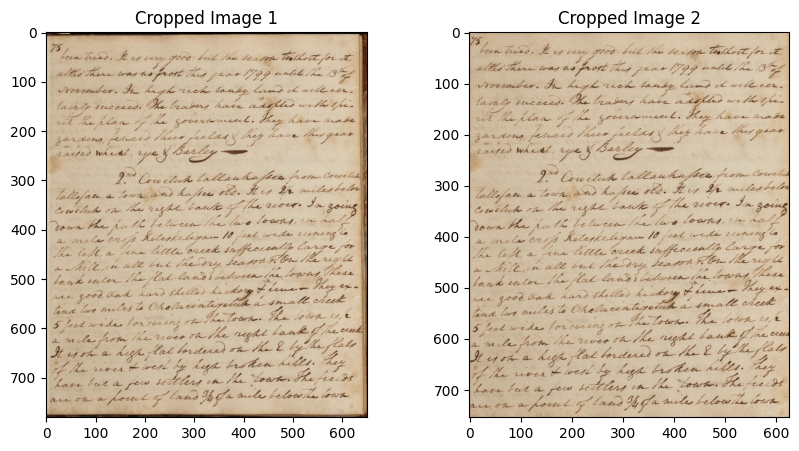

In [25]:
#look at an image from the cropped folder to see how it turned out

path1 =r'C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\cropped_images\991411418805867_Ayer_MS_370_00040-1.jpg'
path2 =r'C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\cropped_images2\991411418805867_Ayer_MS_370_00040-1.jpg'

import matplotlib.pyplot as plt
img1 = plt.imread(path1)
img2 = plt.imread(path2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("Cropped Image 1")
plt.axis('on')
plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("Cropped Image 2")
plt.axis('on')
plt.show()

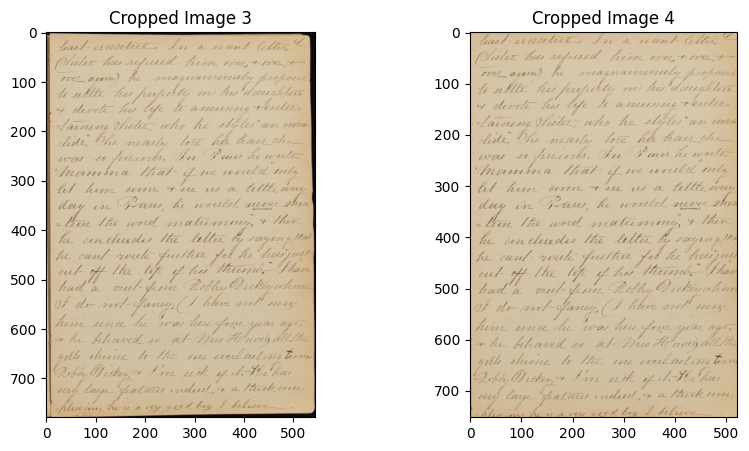

In [26]:
path3 =r'C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\cropped_images\995745818805867_case_ms_4a_31_007-1.jpg'
path4 =r'C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\cropped_images2\995745818805867_case_ms_4a_31_007-1.jpg'


img3 = plt.imread(path3)
img4 = plt.imread(path4)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img3)
plt.title("Cropped Image 3")
plt.axis('on')
plt.subplot(1, 2, 2)
plt.imshow(img4)
plt.title("Cropped Image 4")
plt.axis('on')
plt.show()




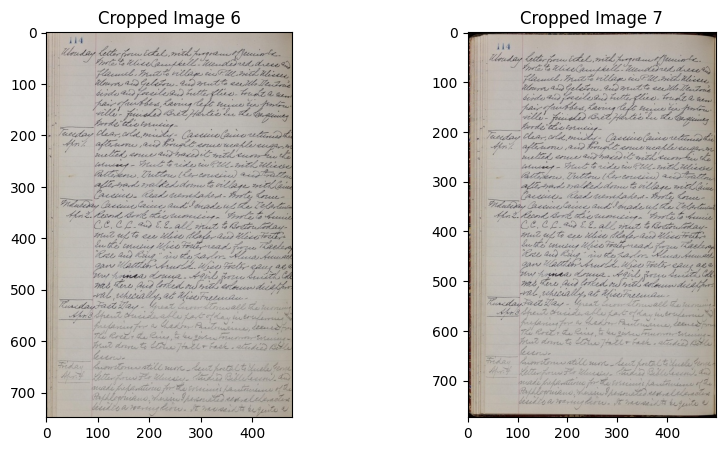

In [27]:
path5 =r'C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\cropped_images2\998217878805867_mms_metcalf_box_12_fl_276_001_136.jpg'
path6 =r'C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\cropped_images2\998217878805867_mms_metcalf_box_12_fl_275_001_118.jpg'
path7 =r'C:\Users\pmlma\.vscode\Math_804_transcription_project\word-segmentation-proj\cropped_images\998217878805867_mms_metcalf_box_12_fl_275_001_118.jpg'

img5 = plt.imread(path5)
img6 = plt.imread(path6)
img7 = plt.imread(path7)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img6)
plt.title("Cropped Image 6")
plt.axis('on')
plt.subplot(1, 2, 2)
plt.imshow(img7)
plt.title("Cropped Image 7")
plt.axis('on')
plt.show()